# 02 — Treatment Assignment (multi-arm + stratification) and Balance Diagnostics

This notebook demonstrates how to:
1. Assign treatment in a randomized experiment with **multiple arms** (e.g., Control / Variant A / Variant B)
2. Use **stratified (blocked) assignment** to reduce imbalance
3. Evaluate covariate balance using **Standardized Mean Differences (SMD)**

The goal is to make assignment reproducible, transparent, and easy to validate.



In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from causalx.assignment import assign_treatment, assign_treatment_stratified, smd


## 1) Create a toy dataset

We'll simulate:
- numeric covariates (`age`, `prior_spend`)
- a binary covariate (`is_mobile`)
- a categorical covariate (`region`) which we will **one-hot encode** for balance checking

Why encode categoricals?
- `smd()` expects numeric columns.
- One-hot encoding converts categories into numeric indicator columns.


In [3]:
rng = np.random.default_rng(0)
n = 5000

df = pd.DataFrame({
    "user_id": np.arange(n),
    "age": rng.normal(35, 10, size=n).clip(18, 80),
    "prior_spend": rng.lognormal(mean=3.2, sigma=0.6, size=n),
    "is_mobile": rng.random(n) < 0.55,
    "region": rng.choice(["NE", "MW", "S", "W"], size=n, p=[0.2, 0.25, 0.35, 0.2]),
})

df.head()


,user_id,age,prior_spend,is_mobile,region
0,0,36.257302,22.021416,True,MW
1,1,33.678951,72.619537,True,NE
2,2,41.404227,30.174118,True,S
3,3,36.049001,16.153634,True,NE
4,4,29.643306,32.658436,False,NE


In [4]:
## One-hot encode region for balance check

df_enc = df.copy()
region_dummies = pd.get_dummies(df_enc["region"], prefix="region", drop_first=False)
df_enc = pd.concat([df_enc.drop(columns=["region"]), region_dummies], axis=1)

covariates = ["age", "prior_spend", "is_mobile"] + list(region_dummies.columns)
covariates


['age',
 'prior_spend',
 'is_mobile',
 'region_MW',
 'region_NE',
 'region_S',
 'region_W']

## 2) Multi-arm random assignment

We assign each user to one of three arms:
- `control`
- `variant_a`
- `variant_b`

We also specify assignment probabilities:
- 50% control, 25% A, 25% B

Key ideas:
- Use a `seed` to make results **reproducible**
- Assignment should not depend on outcome (we don't simulate outcomes here)


In [5]:
assigned = assign_treatment(
    df_enc,
    arms=("control", "variant_a", "variant_b"),
    probs=(0.50, 0.25, 0.25),
    seed=42,
    treatment_col="arm",
)

assigned["arm"].value_counts(normalize=True)


arm
control      0.509
variant_b    0.248
variant_a    0.243
Name: proportion, dtype: float64

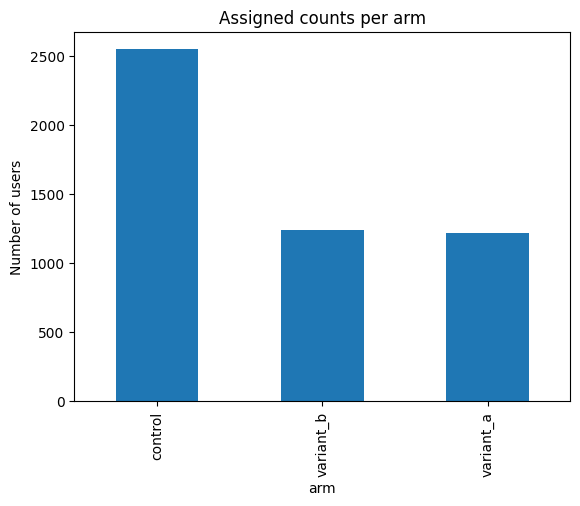

In [6]:
counts = assigned["arm"].value_counts()
plt.figure()
counts.plot(kind="bar")
plt.title("Assigned counts per arm")
plt.ylabel("Number of users")
plt.show()


## 3) Balance diagnostics with SMD

**Standardized Mean Difference (SMD)** compares covariate means between groups:
- SMD near 0 → good balance
- Large absolute SMD → imbalance

Rules of thumb (very common, not strict):
- `|SMD| < 0.10` often considered "good"
- `|SMD| < 0.20` sometimes acceptable depending on context

We'll compute SMD with:
- `reference="control"`
- and also look at `smd_max_pairwise` across all arm pairs


In [7]:
bal = smd(
    assigned,
    covariate_cols=covariates,
    treatment_col="arm",
    reference="control",
)

bal.sort_values("smd_max_pairwise", ascending=False).head(10)


,reference,n_variant_b,mean_variant_b,std_variant_b,n_control,mean_control,std_control,n_variant_a,mean_variant_a,std_variant_a,smd_variant_b_vs_control,smd_variant_a_vs_control,smd_max_pairwise
covariate,,,,,,,,,,,,,
is_mobile,control,1240,0.540323,0.498573,2545,0.535953,0.498804,1215,0.574486,0.494624,0.008762,0.077575,0.077575
region_NE,control,1240,0.208871,0.406666,2545,0.183890,0.387471,1215,0.181893,0.385915,0.062895,-0.005164,0.068053
age,control,1240,34.812359,9.364504,2545,35.173484,9.691677,1215,35.337815,9.626538,-0.037895,0.017013,0.055332
region_MW,control,1240,0.236290,0.424974,2545,0.253438,0.435065,1215,0.239506,0.426958,-0.039874,-0.032322,0.039874
prior_spend,control,1240,30.119418,19.504207,2545,29.420210,18.609771,1215,29.436369,19.256497,0.036680,0.000853,0.036680
region_S,control,1240,0.362097,0.480801,2545,0.367780,0.482296,1215,0.378601,0.485238,-0.011802,0.022368,0.034168
region_W,control,1240,0.192742,0.394611,2545,0.194892,0.396195,1215,0.200000,0.400165,-0.005437,0.012828,0.018264


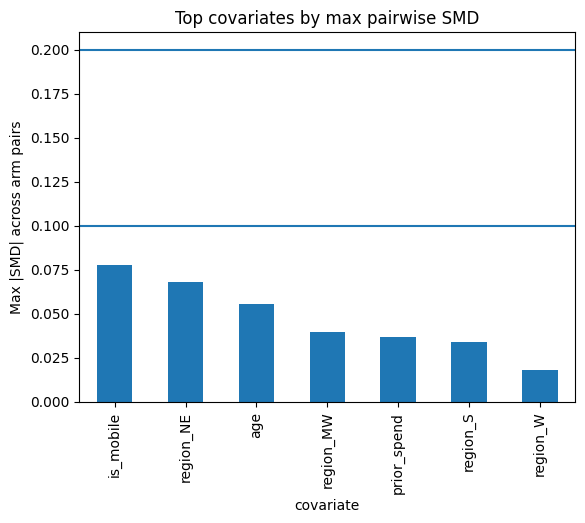

In [8]:
plt.figure()
bal["smd_max_pairwise"].sort_values(ascending=False).head(15).plot(kind="bar")
plt.axhline(0.10)
plt.axhline(0.20)
plt.title("Top covariates by max pairwise SMD")
plt.ylabel("Max |SMD| across arm pairs")
plt.show()


## 4) Stratified (blocked) assignment

Random assignment is unbiased, but by chance you can still get imbalance.

**Stratified assignment** reduces that risk by randomizing *within* groups ("strata").
A very common stratification variable is a categorical attribute like **region**.

In this section we will:
- stratify assignment using the original `region` column (easy and intuitive)
- compute SMD using one-hot encoded `region_*` columns (because SMD expects numeric inputs)



In [9]:
# Keep region as a categorical column for stratification
df_for_assignment = df.copy()

# For balance diagnostics (SMD), we need numeric columns -> one-hot encode region
df_for_balance = df.copy()
region_dummies = pd.get_dummies(df_for_balance["region"], prefix="region", drop_first=False)
df_for_balance = pd.concat([df_for_balance.drop(columns=["region"]), region_dummies], axis=1)

covariates_balance = ["age", "prior_spend", "is_mobile"] + list(region_dummies.columns)

df_for_assignment.head(), df_for_balance.head()



(   user_id        age  prior_spend  is_mobile region
 0        0  36.257302    22.021416       True     MW
 1        1  33.678951    72.619537       True     NE
 2        2  41.404227    30.174118       True      S
 3        3  36.049001    16.153634       True     NE
 4        4  29.643306    32.658436      False     NE,
    user_id        age  prior_spend  is_mobile  region_MW  region_NE  region_S  \
 0        0  36.257302    22.021416       True       True      False     False   
 1        1  33.678951    72.619537       True      False       True     False   
 2        2  41.404227    30.174118       True      False      False      True   
 3        3  36.049001    16.153634       True      False       True     False   
 4        4  29.643306    32.658436      False      False       True     False   
 
    region_W  
 0     False  
 1     False  
 2     False  
 3     False  
 4     False  )

In [10]:
assigned_strat = assign_treatment_stratified(
    df_for_assignment,
    strata_cols="region",  # <- the key improvement: stratify on the original categorical column
    arms=("control", "variant_a", "variant_b"),
    probs=(0.50, 0.25, 0.25),
    seed=42,
    treatment_col="arm",
)

assigned_strat["arm"].value_counts(normalize=True)



arm
control      0.5002
variant_a    0.2500
variant_b    0.2498
Name: proportion, dtype: float64

In [11]:
# Join the assigned arm labels (from df_for_assignment) onto the balance dataframe.
# They have the same row order / index, so this is safe.
balance_df_strat = df_for_balance.copy()
balance_df_strat["arm"] = assigned_strat["arm"].values

balance_df_strat.head()



,user_id,age,prior_spend,is_mobile,region_MW,region_NE,region_S,region_W,arm
0,0,36.257302,22.021416,True,True,False,False,False,control
1,1,33.678951,72.619537,True,False,True,False,False,variant_a
2,2,41.404227,30.174118,True,False,False,True,False,control
3,3,36.049001,16.153634,True,False,True,False,False,control
4,4,29.643306,32.658436,False,False,True,False,False,control


In [14]:
bal_strat = smd(
    balance_df_strat,
    covariate_cols=covariates_balance,
    treatment_col="arm",
    reference="control",
)

bal_strat.sort_values("smd_max_pairwise", ascending=False).head(10)




,reference,n_control,mean_control,std_control,n_variant_a,mean_variant_a,std_variant_a,n_variant_b,mean_variant_b,std_variant_b,smd_variant_a_vs_control,smd_variant_b_vs_control,smd_max_pairwise
covariate,,,,,,,,,,,,,
age,control,2501,35.182931,9.550919,1250,35.394191,9.905937,1249,34.735017,9.362306,0.021712,-0.047363,0.068394
is_mobile,control,2501,0.545382,0.498036,1250,0.562400,0.496290,1249,0.532426,0.499147,0.034231,-0.025985,0.060223
prior_spend,control,2501,29.260981,18.527500,1250,30.278775,20.239938,1249,29.589687,18.611730,0.052456,0.017701,0.052456
region_W,control,2501,0.195522,0.396681,1250,0.196000,0.397127,1249,0.195356,0.396634,0.001205,-0.000417,0.001622
region_MW,control,2501,0.245902,0.430707,1250,0.245600,0.430615,1249,0.245797,0.430731,-0.000700,-0.000244,0.000700
region_S,control,2501,0.369052,0.482645,1250,0.368800,0.482673,1249,0.369095,0.482753,-0.000523,0.000089,0.000612
region_NE,control,2501,0.189524,0.392003,1250,0.189600,0.392141,1249,0.189752,0.392262,0.000193,0.000580,0.000580


In [15]:
# Prepare the balance dataframe for RANDOM assignment as well (same covariates_balance)
balance_df_random = df_for_balance.copy()
balance_df_random["arm"] = assigned["arm"].values  # from earlier random assignment section

bal_random = smd(
    balance_df_random,
    covariate_cols=covariates_balance,
    treatment_col="arm",
    reference="control",
)

summary = pd.DataFrame(
    {
        "max_pairwise_smd": [bal_random["smd_max_pairwise"].max(), bal_strat["smd_max_pairwise"].max()],
        "mean_pairwise_smd": [bal_random["smd_max_pairwise"].mean(), bal_strat["smd_max_pairwise"].mean()],
    },
    index=["Random assignment", "Stratified assignment"],
)

summary



,max_pairwise_smd,mean_pairwise_smd
Random assignment,0.077575,0.047135
Stratified assignment,0.068394,0.026370


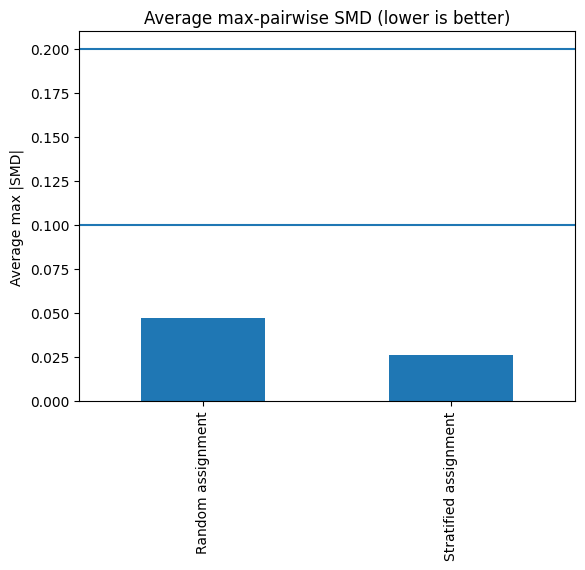

In [16]:
plt.figure()
summary["mean_pairwise_smd"].plot(kind="bar")
plt.axhline(0.10)
plt.axhline(0.20)
plt.title("Average max-pairwise SMD (lower is better)")
plt.ylabel("Average max |SMD|")
plt.show()


### Interpretation

- Stratification makes each arm more comparable **within each region**.
- In many practical cases, this reduces the *typical size* of imbalances (e.g., mean/max SMD).
- Even with stratification, it’s still good practice to check balance.

Tip: You can stratify on multiple columns (e.g., `["region", "is_mobile"]`) to block on multiple important covariates.


### Sanity check: treatment proportions within each region

With stratified assignment, each region should have approximately the same
treatment proportions as the overall target (subject to rounding).

This table shows the fraction of users in each arm *within each region*.


In [17]:
(
    assigned_strat
    .groupby(["region", "arm"])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
    .rename("proportion")
    .reset_index()
    .pivot(index="region", columns="arm", values="proportion")
    .round(3)
)


ValueError: cannot insert region, already exists